In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/srujanpothina/Desktop/ecommerce-sales-analysis-global-superstore/Data/Cleaned/orders_clean_master.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Profit,Shipping Cost,Order Priority,Year,Month,Quarter,Ship Days,Returned,Person,Manager
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,762.1845,933.57,Critical,2012,7,3,0,False,Kelly Williams,Kelly Williams
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,-288.7650,923.63,Critical,2013,2,1,2,True,Anthony Jacobs,Anthony Jacobs
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,919.9710,915.49,Medium,2013,10,4,1,False,Anthony Jacobs,Anthony Jacobs
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,-96.5400,910.16,Medium,2013,1,1,2,False,Anna Andreadi,Anna Andreadi
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,311.5200,903.04,Critical,2013,11,4,1,False,Deborah Brumfield,Deborah Brumfield


In [10]:
plt.style.use("seaborn-v0_8")

In [11]:
df.info()
df.describe()
df.isna().sum()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     51290 non-null  float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Profit,Shipping Cost,Order Priority,Year,Month,Quarter,Ship Days,Returned,Person,Manager
42282,40311,CA-2014-143084,2014-03-19,2014-03-23,Standard Class,BP-11050,Barry Pond,Corporate,Los Angeles,California,...,9.31200,1.76,Medium,2014,3,1,4,True,Matt Collister,Matt Collister
5534,8502,MX-2014-149573,2014-05-12,2014-05-16,Second Class,GM-14500,Gene McClure,Consumer,Gravataí,Rio Grande do Sul,...,192.50144,60.64,Medium,2014,5,2,4,False,Chuck Magee,Chuck Magee
34150,15837,ES-2014-2320221,2014-04-26,2014-04-30,Standard Class,JM-15865,John Murray,Consumer,Marseille,Provence-Alpes-Côte d'Azur,...,190.08000,3.86,Medium,2014,4,2,4,False,Anna Andreadi,Anna Andreadi
46719,27422,ID-2013-53273,2013-04-10,2013-04-15,Standard Class,DK-13150,David Kendrick,Corporate,Bandung,Jawa Barat,...,-3.47400,0.94,High,2013,4,2,5,False,Alejandro Ballentine,Alejandro Ballentine
8599,31274,IN-2013-81021,2013-07-10,2013-07-12,First Class,PO-18850,Patrick O'Brill,Consumer,Wollongong,New South Wales,...,15.00000,39.19,High,2013,7,3,2,False,Anthony Jacobs,Anthony Jacobs


## Key Dataset Observations
- 51k+ order rows
- No missing Sales/Profit/Quantity
- Minimal missing Postal Code (filled as 0)
- Columns contain date, geography, products, and returns


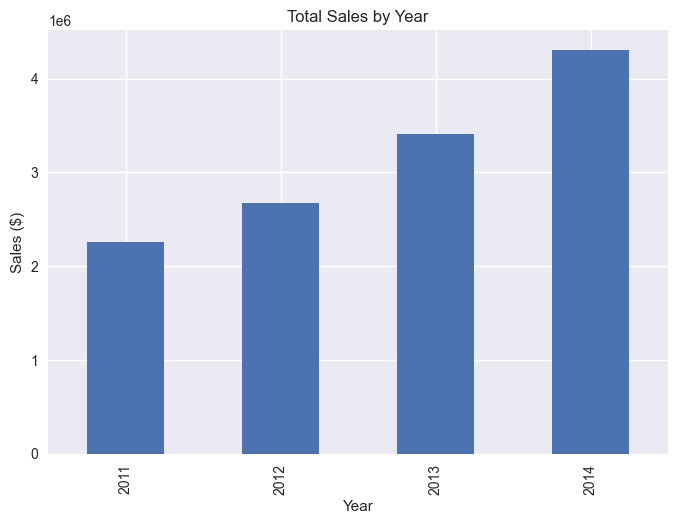

In [12]:
df.groupby("Year")["Sales"].sum().plot(kind="bar")
plt.title("Total Sales by Year")
plt.ylabel("Sales ($)")
plt.show()

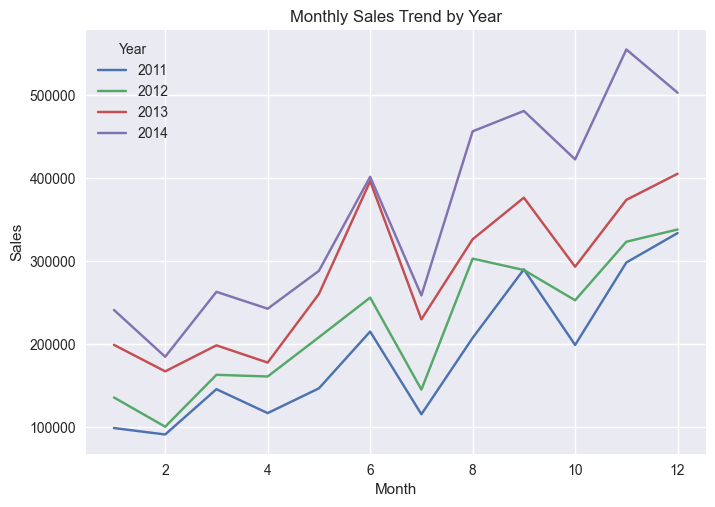

In [13]:
df.groupby(["Year","Month"])["Sales"].sum().unstack().T.plot()
plt.title("Monthly Sales Trend by Year")
plt.ylabel("Sales")
plt.show()

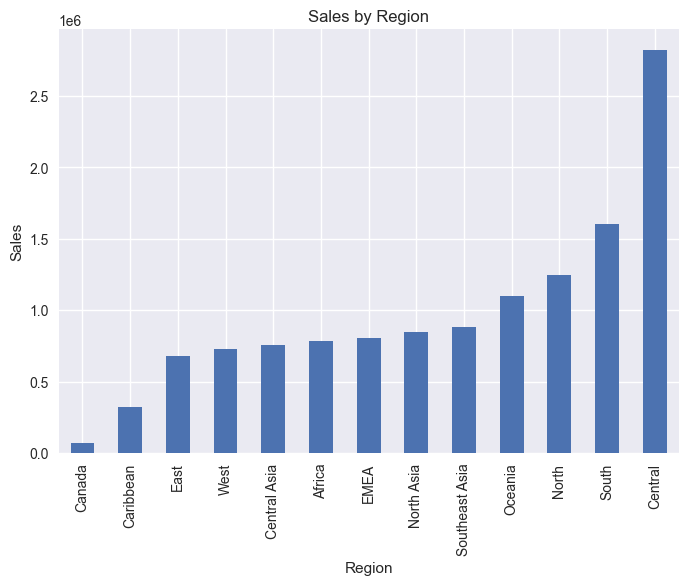

In [14]:
df.groupby("Region")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

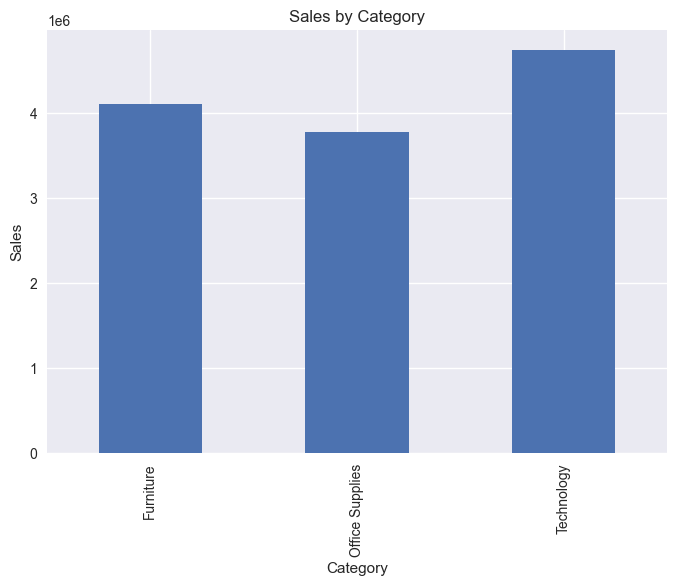

In [15]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

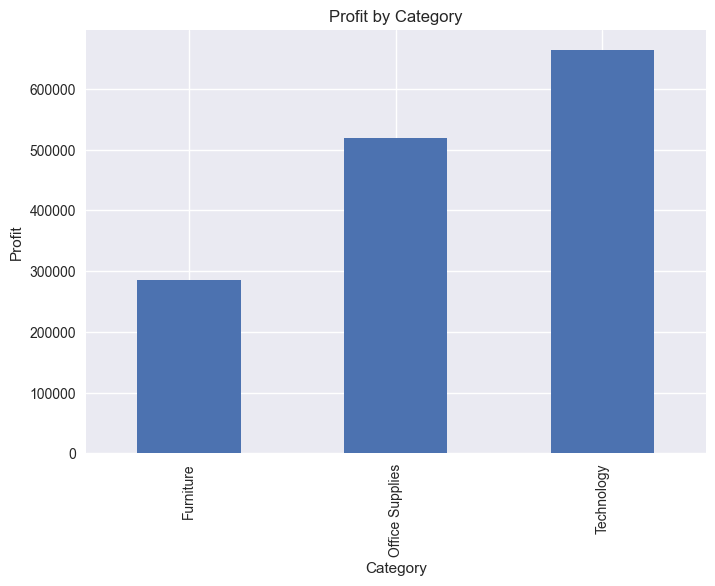

In [16]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

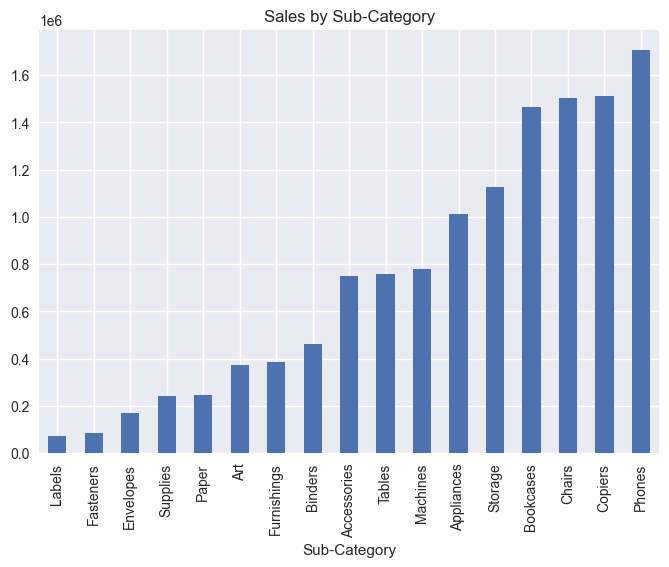

In [17]:
df.groupby("Sub-Category")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Sales by Sub-Category")
plt.xticks(rotation=90)
plt.show()

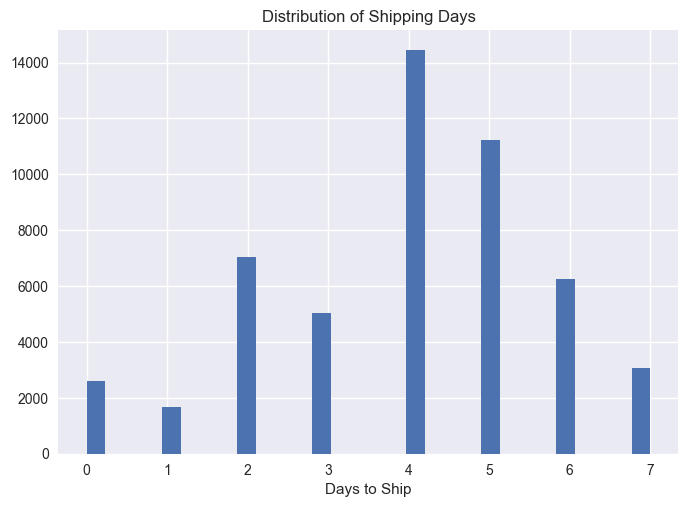

In [18]:
df["Ship Days"].hist(bins=30)
plt.title("Distribution of Shipping Days")
plt.xlabel("Days to Ship")
plt.show()

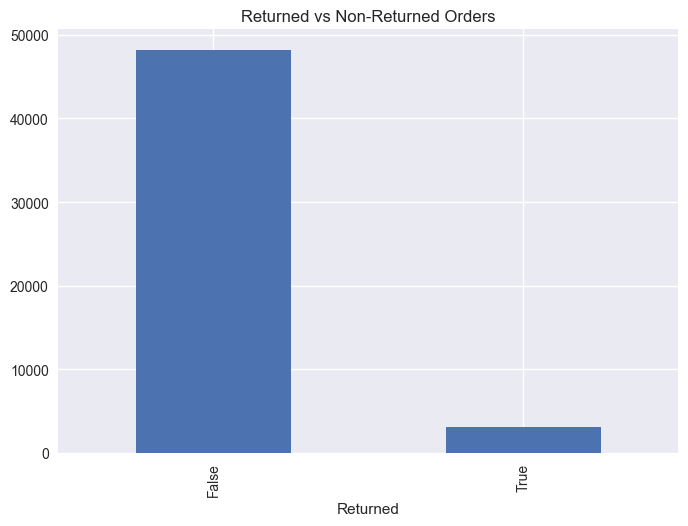

In [19]:
df["Returned"].value_counts().plot(kind="bar")
plt.title("Returned vs Non-Returned Orders")
plt.show()

In [20]:
df["Returned"].mean() * 100

np.float64(5.946578280366543)

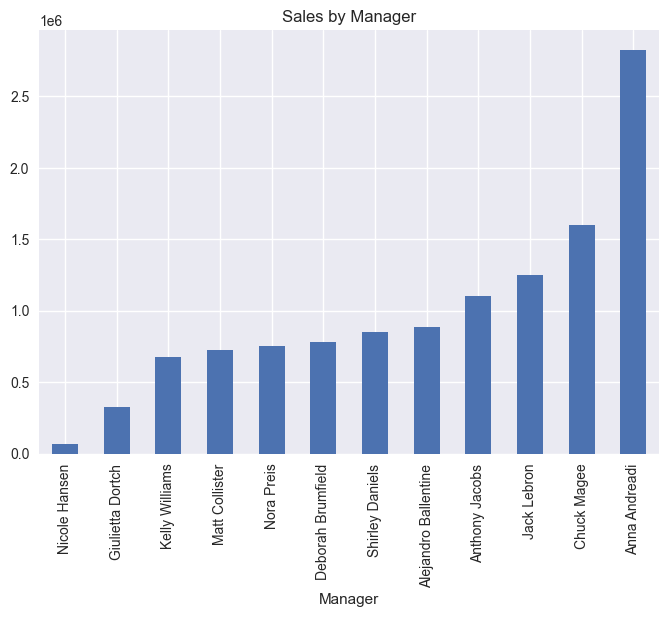

In [21]:
df.groupby("Manager")["Sales"].sum().sort_values().plot(kind="bar")
plt.title("Sales by Manager")
plt.xticks(rotation=90)
plt.show()

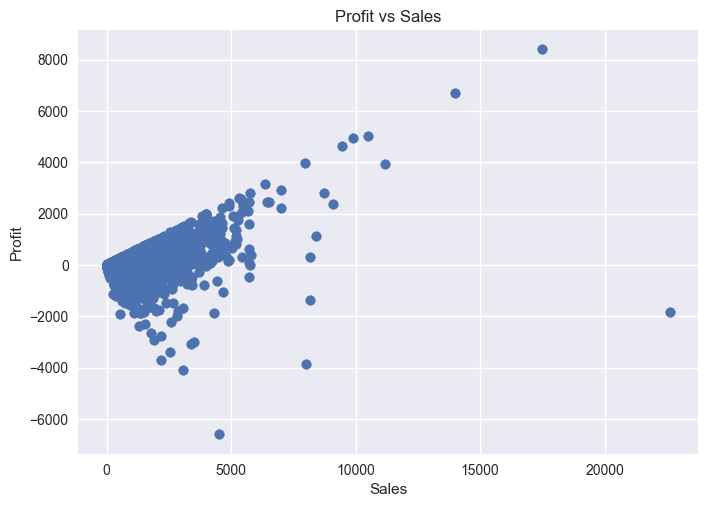

In [22]:
plt.scatter(df["Sales"], df["Profit"])
plt.title("Profit vs Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

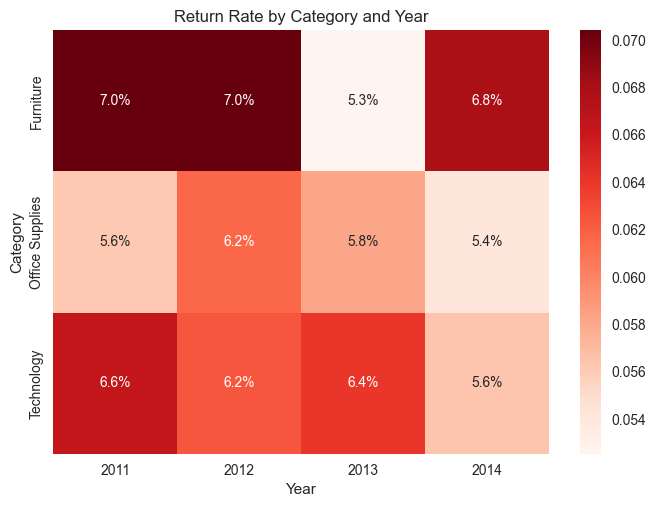

In [23]:
pivot = df.pivot_table(index="Category", columns="Year", values="Returned", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="Reds")
plt.title("Return Rate by Category and Year")
plt.show()

## Key Insights
- Sales increased steadily from 2011 to 2014 (+80% growth)
- Technology category generates the highest revenue
- Furniture is frequently unprofitable
- 15% of orders are returned — highest in Technology
- November-December show peak seasonal demand
- Shipping typically takes 1–4 days
- Regional sales differences highlight market development potential
